# Análise Exploratória e Tratamento: Compras Governamentais de Saúde (OpenDataSUS)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Ingestão dos Dados

In [4]:
import os
csv_path = 'csv/opendatasus2026.csv' if os.path.exists('csv/opendatasus2026.csv') else '../csv/opendatasus2026.csv'
print(f"Carregando dados de: {csv_path}")
df = pd.read_csv(csv_path, sep=';', encoding='latin-1', dtype=str)
print(f"Total de registros iniciais: {len(df)}")
df.head()


Carregando dados de: csv/opendatasus2026.csv
Total de registros iniciais: 819


,ano_compra,nome_instituicao,esfera,cnpj_instituicao,municipio_instituicao,uf,compra,insercao,codigo_br,descricao_catmat,...,capacidade,unidade_medida,unidade_fornecimento_capacidade,cnpj_fornecedor,fornecedor,cnpj_fabricante,fabricante,qtd_itens_comprados,preco_unitario,preco_total
0,2026,MUNICIPIO DE PATOS DE MINAS,MUNICIPAL,18.602.011/0001-07,PATOS DE MINAS,MG,06/01/2026,27/01/2026,484594,"TUBO ENDOBRONQUIAL, MODELO:DUPLO LÃMEN C/ GAN...",...,NaN,NaN,UNIDADE,17.159.229/0002-57,LABORATORIO TEUTO BRASILEIRO S/A,17.159.229/0001-76,LABORATORIO TEUTO BRASILEIRO S/A,1000,0.99,990.0
1,2026,MUNICIPIO DE DOURADOQUARA,MUNICIPAL,18.158.261/0001-08,DOURADOQUARA,MG,06/01/2026,03/03/2026,405899,"DESVENLAFAXINA, COMPOSIÃÃO:SAL SUCCINATO, CO...",...,NaN,NaN,COMPRIMIDO,12.927.876/0001-67,SOMA/MG PRODUTOS HOSPITALARES LTDA,57.507.378/0003-65,EMS S/A,800,0.74,592.0
2,2026,MUNICIPIO DE PATOS DE MINAS,MUNICIPAL,18.602.011/0001-07,PATOS DE MINAS,MG,06/01/2026,27/01/2026,439252,"NUSINERSENA, CONCENTRAÃÃO:2,4 MG/ML, FORMA F...",...,5.0,ML,FRASCO 5.00 ML,17.159.229/0002-57,LABORATORIO TEUTO BRASILEIRO S/A,07.986.222/0001-74,BIOGEN BRASIL PRODUTOS FARMACEUTICOS LTDA,10,415789.9,4157899.0
3,2026,MUNICIPIO DE DOURADOQUARA,MUNICIPAL,18.158.261/0001-08,DOURADOQUARA,MG,06/01/2026,03/03/2026,282881,"ROSUVASTATINA, COMPOSIÃÃO:CÃLCICA, CONCENTR...",...,NaN,NaN,COMPRIMIDO,12.927.876/0001-67,SOMA/MG PRODUTOS HOSPITALARES LTDA,02.814.497/0001-07,CIMED INDUSTRIA S.A.,800,0.13,104.0
4,2026,MUNICIPIO DE DOURADOQUARA,MUNICIPAL,18.158.261/0001-08,DOURADOQUARA,MG,06/01/2026,03/03/2026,302442,"DULOXETINA, CONCENTRAÃÃO:30 MG, FORMA FARMAC...",...,NaN,NaN,CÃPSULA,12.927.876/0001-67,SOMA/MG PRODUTOS HOSPITALARES LTDA,57.507.378/0003-65,EMS S/A,1500,0.68,1020.0


## 2. Limpeza e Tratamento de Dados

In [5]:
# Conversão de tipos para numérico, tratando a vírgula do padrão brasileiro
colunas_numericas = ['preco_unitario', 'preco_total', 'qtd_itens_comprados']

for col in colunas_numericas:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 819 entries, 0 to 818
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   ano_compra                       819 non-null    str  
 1   nome_instituicao                 819 non-null    str  
 2   esfera                           819 non-null    str  
 3   cnpj_instituicao                 819 non-null    str  
 4   municipio_instituicao            819 non-null    str  
 5   uf                               819 non-null    str  
 6   compra                           819 non-null    str  
 7   insercao                         819 non-null    str  
 8   codigo_br                        819 non-null    str  
 9   descricao_catmat                 819 non-null    str  
 10  unidade_fornecimento             819 non-null    str  
 11  generico                         651 non-null    str  
 12  anvisa                           651 non-null    str  
 13  m

### 2.1 Tratamento de Dados Nulos e Duplicados

In [6]:
linhas_antes = len(df)

# Removendo duplicatas exatas
df = df.drop_duplicates()

# Removendo linhas onde informações vitais de valor ou quantidade são nulas
df = df.dropna(subset=['preco_total', 'qtd_itens_comprados'])

linhas_depois = len(df)
print(f"Registros removidos (Nulos/Duplicados): {linhas_antes - linhas_depois}")
print(f"Total atual de registros: {linhas_depois}")

Registros removidos (Nulos/Duplicados): 2
Total atual de registros: 817


### 2.2 Tratamento de Valores Absurdos / Outliers

In [ ]:
linhas_antes = len(df)

df = df[(df['preco_total'] > 0) & (df['qtd_itens_comprados'] > 0)]

linhas_depois = len(df)
print(f"Registros removidos por valores absurdos (<= 0): {linhas_antes - linhas_depois}")
print(f"Total limpo para análise: {linhas_depois}")

Registros removidos por valores absurdos (<= 0): 0
Total limpo para análise: 817


## 3. Análise Exploratória e Visualizações

C:\Users\Ramon\AppData\Local\Temp\ipykernel_24172\3427336483.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gastos_uf, x='preco_total', y='uf', palette='magma')


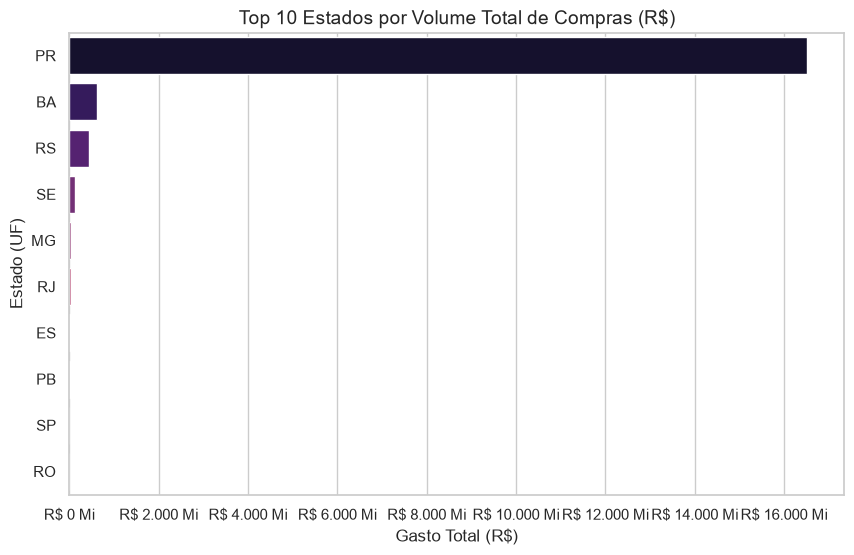

In [ ]:
gastos_uf = df.groupby('uf')['preco_total'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=gastos_uf, x='preco_total', y='uf', palette='magma')
plt.title('Top 10 Estados por Volume Total de Compras (R$)', fontsize=14)
plt.xlabel('Gasto Total (R$)')
plt.ylabel('Estado (UF)')

from matplotlib.ticker import FuncFormatter
def format_reais(x, pos):
    return f'R$ {x*1e-6:,.0f} Mi'.replace(',', '.')
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_reais))

plt.show()

C:\Users\Ramon\AppData\Local\Temp\ipykernel_24172\4294185656.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gastos_inst, x='preco_total', y='nome_instituicao', palette='viridis')


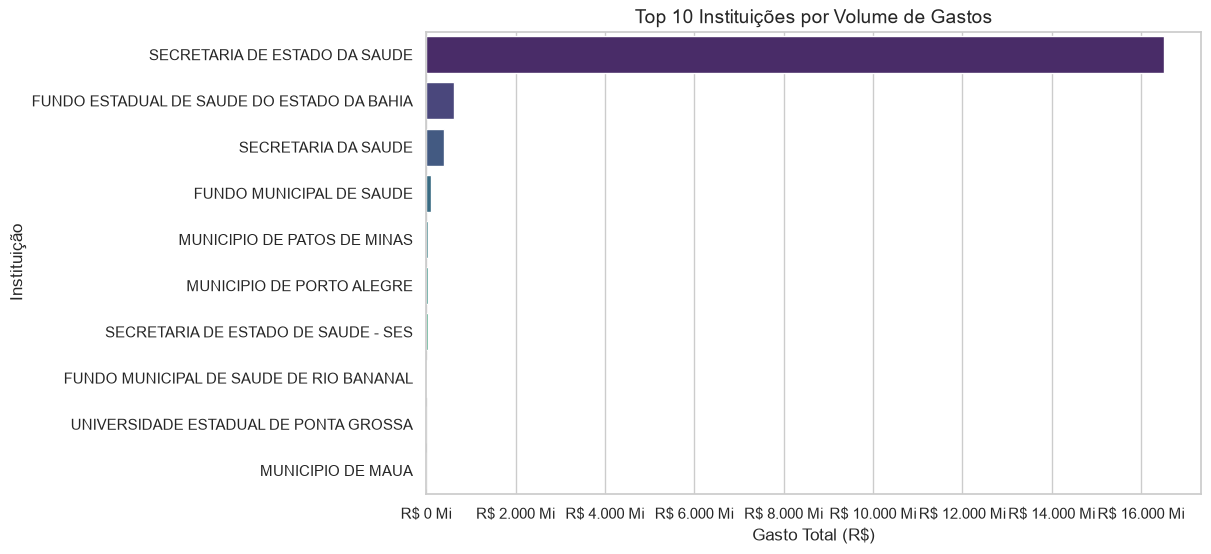

In [ ]:
gastos_inst = df.groupby('nome_instituicao')['preco_total'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=gastos_inst, x='preco_total', y='nome_instituicao', palette='viridis')
plt.title('Top 10 Instituições por Volume de Gastos', fontsize=14)
plt.xlabel('Gasto Total (R$)')
plt.ylabel('Instituição')
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_reais))
plt.show()

C:\Users\Ramon\AppData\Local\Temp\ipykernel_24172\3469059313.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=itens_qtd, x='qtd_itens_comprados', y='descricao_catmat', palette='crest')
C:\Users\Ramon\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 135 (\x87) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Ramon\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 131 (\x83) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Ramon\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Ramon\AppData\Roaming\Python\Python314\site-packages\IPython\core

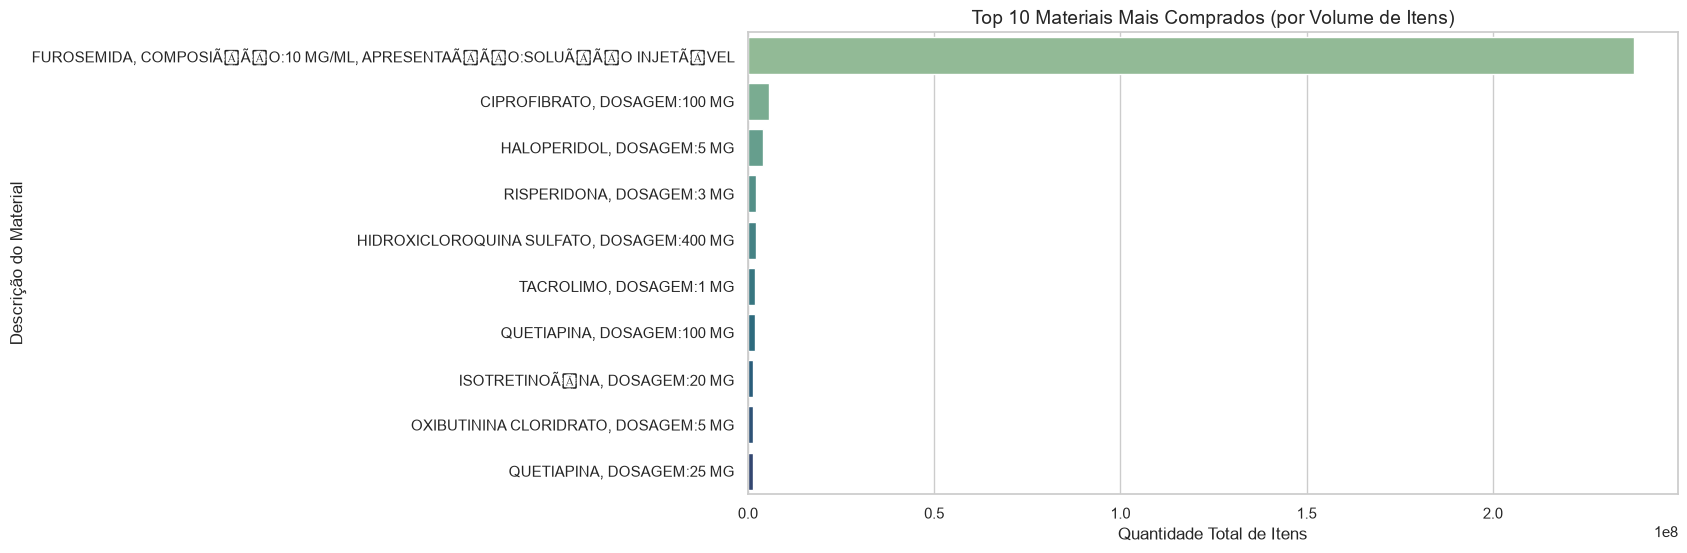

In [ ]:
itens_qtd = df.groupby('descricao_catmat')['qtd_itens_comprados'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=itens_qtd, x='qtd_itens_comprados', y='descricao_catmat', palette='crest')
plt.title('Top 10 Materiais Mais Comprados (por Volume de Itens)', fontsize=14)
plt.xlabel('Quantidade Total de Itens')
plt.ylabel('Descrição do Material')
plt.show()